In [1]:
# Set this once per environment. Must point to apps/pytorch-engine.
# Colab example: Path("/content/pytorch-engine")
import logging
import os
import sys
from pathlib import Path

ENGINE_ROOT = Path(r"/content").resolve()
SRC_ROOT = ENGINE_ROOT
if not (SRC_ROOT / "pytorch_engine").is_dir():
    raise ValueError(
        f"ENGINE_ROOT must point to pytorch-engine app root. Missing package directory: {SRC_ROOT / 'pytorch_engine'}"
    )
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))


In [2]:
!pip install torchinfo

In [3]:
import pandas as pd
import torch
from pytorch_engine import (
    ChestXrayTrainingConfig,
    build_chest_xray_imagefolder_loaders,
    create_milestone_checkpoint_callback,
    download_and_prepare_kaggle_chest_xray_pneumonia_dataset,
    resolve_device,
    run_chest_xray_effnet_training,
    summarize_imagefolder_splits,
)
from pytorch_engine.visualization import plot_confusion_matrix, plot_loss_curves
from torchinfo import summary
from google.colab import userdata

In [4]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    force=True,
)

device = resolve_device("auto")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    free_memory_bytes, total_memory_bytes = torch.cuda.mem_get_info()

    # TF32 is valuable on Ampere+ hardware such as A100. It speeds up many
    # float32 kernels without changing user code.
    use_tf32 = gpu_capability >= (8, 0)
    torch.backends.cuda.matmul.allow_tf32 = use_tf32
    torch.backends.cudnn.allow_tf32 = use_tf32
    torch.backends.cudnn.benchmark = True
    if use_tf32:
        torch.set_float32_matmul_precision("high")
else:
    gpu_name = "cpu"
    gpu_capability = None
    free_memory_bytes = None
    total_memory_bytes = None
    use_tf32 = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.backends.cudnn.benchmark = False

DATASET_ROOT = Path(
    os.getenv(
        "CHEST_XRAY_DATASET_ROOT",
        str(ENGINE_ROOT / "data" / "chest-xray-pneumonia-balanced-dataset"),
    )
)
DATASET_ROOT = download_and_prepare_kaggle_chest_xray_pneumonia_dataset(destination=DATASET_ROOT)
OUTPUT_DIR = Path(
    os.getenv(
        "CHEST_XRAY_OUTPUT_DIR",
        str(ENGINE_ROOT / "src" / "pytorch-saved-models" / "effnetb0_chest_xray"),
    )
)

# Windows notebook kernels often behave better with single-process loading.
NUM_WORKERS = 0 if os.name == "nt" else None
BATCH_SIZE = int(os.getenv("CHEST_XRAY_BATCH_SIZE", "32" if device.type == "cuda" else "16"))

config = ChestXrayTrainingConfig(
    dataset_root=DATASET_ROOT,
    output_dir=OUTPUT_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    compile_model=device.type == "cuda",
    compile_mode="max-autotune",
    use_amp=device.type == "cuda",
    use_channels_last=device.type == "cuda",
    fine_tune_epoch_end_callback=None,
)

runtime_summary = pd.DataFrame(
    [
        {
            "setting": "dataset_root",
            "value": str(config.dataset_root),
            "notes": "Must contain train/val/test with NORMAL and PNEUMONIA folders.",
        },
        {
            "setting": "output_dir",
            "value": str(config.output_dir),
            "notes": "Best and last checkpoints are written here.",
        },
        {
            "setting": "device",
            "value": str(device),
            "notes": "CUDA enables AMP, channels-last, and optional torch.compile.",
        },
        {
            "setting": "batch_size",
            "value": config.batch_size,
            "notes": "32 is the default full-training baseline for T4-class GPUs.",
        },
        {
            "setting": "num_workers",
            "value": config.num_workers,
            "notes": "None means shared loader will choose a good default; Windows stays at 0 here.",
        },
        {
            "setting": "head_warmup_epochs",
            "value": config.head_warmup_epochs,
            "notes": "Short head-only warmup stabilizes transfer learning on a small binary dataset.",
        },
        {
            "setting": "fine_tune_epochs",
            "value": config.fine_tune_epochs,
            "notes": "Main fine-tuning stage after selective unfreezing.",
        },
        {
            "setting": "trainable_feature_blocks",
            "value": config.trainable_feature_blocks,
            "notes": "Only the last EfficientNet blocks are unfrozen to reduce overfitting.",
        },
        {
            "setting": "selection_metric",
            "value": config.selection_metric,
            "notes": "Best checkpoint and early stopping follow validation AUROC.",
        },
    ]
)
display(runtime_summary)

if device.type == "cuda":
    print(f"GPU: {gpu_name}")
    print(f"Capability: {gpu_capability}")
    print(
        f"GPU memory: {free_memory_bytes / 1e9:.2f} GB free / "
        f"{total_memory_bytes / 1e9:.2f} GB total"
    )
    print(f"TF32 enabled: {use_tf32}")
else:
    print("CUDA not available. Notebook will run on CPU, but full training is tuned for GPU.")


2026-04-18 08:49:25,371 | INFO | pytorch_engine.utils | Auto-detected device: cuda
2026-04-18 08:51:12,554 | INFO | pytorch_engine.data_setup | Extracting dataset '/content/data/chest-xray-pneumonia-balanced-dataset/chest-xray-pneumonia-balanced-dataset.zip' to '/content/data/chest-xray-pneumonia-balanced-dataset'


,setting,value,notes
0,dataset_root,/content/data/chest-xray-pneumonia-balanced-da...,Must contain train/val/test with NORMAL and PN...
1,output_dir,/content/src/pytorch-saved-models/effnetb0_che...,Best and last checkpoints are written here.
2,device,cuda,"CUDA enables AMP, channels-last, and optional ..."
3,batch_size,32,32 is the default full-training baseline for T...
4,num_workers,None,None means shared loader will choose a good de...
5,head_warmup_epochs,1,Short head-only warmup stabilizes transfer lea...
6,fine_tune_epochs,8,Main fine-tuning stage after selective unfreez...
7,trainable_feature_blocks,2,Only the last EfficientNet blocks are unfrozen...
8,selection_metric,auroc,Best checkpoint and early stopping follow vali...


GPU: Tesla T4
Capability: (7, 5)
GPU memory: 15.53 GB free / 15.64 GB total
TF32 enabled: False


In [5]:
milestone_checkpoint_callback_factory = create_milestone_checkpoint_callback

# The shared chest X-ray pipeline supports extra epoch-end callbacks during
# fine-tuning. Leave this disabled in local development.
#
# Uncomment for non-local / longer training runs when you want milestone
# checkpoints along the way, optionally mirrored to Hugging Face.
#
HF_USERNAME = userdata.get("HF_USERNAME")
HF_TOKEN = userdata.get("HF_TOKEN")
HF_REPO_SUBDIR = "effnetb0"
HF_REPO_ID = f"{HF_USERNAME}/{HF_REPO_SUBDIR}" if HF_USERNAME else None
milestone_checkpoint_callback = create_milestone_checkpoint_callback(
    model_name_prefix="effnetb0",
    total_epochs=config.fine_tune_epochs,
    every_n_epochs=5,
    target_dir=str(config.output_dir),
    hf_repo_id=HF_REPO_ID,
    hf_token=HF_TOKEN,
    hf_repo_subdir=HF_REPO_SUBDIR,
    upload_best_checkpoint=False,
)
config.fine_tune_epoch_end_callback = milestone_checkpoint_callback


In [6]:
expected_dirs = [
    DATASET_ROOT / split_name / class_name
    for split_name in ("train", "val", "test")
    for class_name in ("NORMAL", "PNEUMONIA")
]
missing_dirs = [path for path in expected_dirs if not path.is_dir()]
if missing_dirs:
    raise FileNotFoundError(
        "Dataset structure is incomplete. Missing directories:\n" + "\n".join(str(path) for path in missing_dirs)
    )

split_summary = pd.DataFrame(summarize_imagefolder_splits(DATASET_ROOT)).set_index("split")
split_summary["pneumonia_rate"] = split_summary["PNEUMONIA"] / split_summary["total"]
display(split_summary.round(4))

# Preview dataloaders so you can inspect resolved settings before the real run.
preview_loaders = build_chest_xray_imagefolder_loaders(config)
loader_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "batches": len(preview_loaders.train_dataloader),
            "batch_size": preview_loaders.train_dataloader.batch_size,
            "drop_last": preview_loaders.train_dataloader.drop_last,
            "pin_memory": preview_loaders.train_dataloader.pin_memory,
        },
        {
            "split": "val",
            "batches": len(preview_loaders.val_dataloader),
            "batch_size": preview_loaders.val_dataloader.batch_size,
            "drop_last": preview_loaders.val_dataloader.drop_last,
            "pin_memory": preview_loaders.val_dataloader.pin_memory,
        },
        {
            "split": "test",
            "batches": len(preview_loaders.test_dataloader),
            "batch_size": preview_loaders.test_dataloader.batch_size,
            "drop_last": preview_loaders.test_dataloader.drop_last,
            "pin_memory": preview_loaders.test_dataloader.pin_memory,
        },
    ]
)
display(loader_summary)
print(f"Class order: {preview_loaders.class_names}")
print("\nTrain transform:\n", preview_loaders.train_dataloader.dataset.transform)
print("\nEval transform:\n", preview_loaders.val_dataloader.dataset.transform)


,NORMAL,PNEUMONIA,total,pneumonia_rate
split,,,,
train,3400,3400,6800,0.5
val,850,850,1700,0.5
test,15,15,30,0.5


2026-04-18 08:51:32,970 | INFO | pytorch_engine.utils | Auto-detected device: cuda


,split,batches,batch_size,drop_last,pin_memory
0,train,212,32,True,True
1,val,54,32,False,True
2,test,1,32,False,True


Class order: ['NORMAL', 'PNEUMONIA']

Train transform:
 Compose(
    Resize(size=(256, 256), interpolation=bicubic, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomApply(
    p=0.7
    RandomAffine(degrees=[-5.0, 5.0], translate=(0.02, 0.02), scale=(0.95, 1.05), interpolation=bicubic)
)
    RandomApply(
    p=0.3
    ColorJitter(brightness=(0.95, 1.05), contrast=(0.92, 1.08), saturation=None, hue=None)
)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transform:
 Compose(
    Resize(size=(256, 256), interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
run = run_chest_xray_effnet_training(config)

2026-04-18 08:51:33,020 | INFO | pytorch_engine.utils | Auto-detected device: cuda
2026-04-18 08:51:33,042 | INFO | pytorch_engine.models.effnetb0_model_creator | Creating EffNetB0 model - num_classes=2 seed=42 dropout_p=0.20 trainable_feature_blocks=0
2026-04-18 08:51:33,043 | INFO | pytorch_engine.models.effnetb0_model_creator | Loaded pre-trained EfficientNet_B0_Weights


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 77.6MB/s]
2026-04-18 08:51:33,535 | INFO | pytorch_engine.models.effnetb0_model_creator | Frozen 213 parameter groups in backbone
2026-04-18 08:51:33,537 | INFO | pytorch_engine.models.effnetb0_model_creator | Replaced classifier head: in_features=1280 -> out_features=2
2026-04-18 08:51:33,539 | INFO | pytorch_engine.models.effnetb0_model_creator | EffNetB0 model ready - 2562 trainable / 4010110 total parameters
2026-04-18 08:51:33,541 | INFO | pytorch_engine.utils | Auto-detected device: cuda
2026-04-18 08:51:33,589 | INFO | pytorch_engine.training_loop | Training started - model=EfficientNet epochs=1 device=cuda compile=False compile_mode=n/a amp=True channels_last=True


Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-18 08:51:33,600 | INFO | pytorch_engine.utils | Using explicit device: cuda
2026-04-18 08:51:33,611 | INFO | pytorch_engine.training_loop | Train step started on cuda (212 batches)


...

2026-04-18 09:33:54,725 | INFO | pytorch_engine.training_loop | Eval step complete - loss=0.1992 accuracy=0.9618
2026-04-18 09:33:54,750 | INFO | pytorch_engine.training_loop | Epoch 8/8 - train_loss=0.2123 train_acc=0.9596 test_loss=0.1992 test_acc=0.9618 loss_gap=-0.0131 acc_gap=-0.0022 lr=1e-06
2026-04-18 09:33:54,751 | INFO | pytorch_engine.training_loop | Epoch 8 validation metrics - {'accuracy': 0.961764705882353, 'balanced_accuracy': 0.961764705882353, 'macro_f1': 0.9617646926521428, 'macro_precision': 0.9617653450039376, 'macro_recall': 0.961764705882353, 'weighted_f1': 0.9617646926521427, 'auroc': 0.9938712802768166, 'average_precision': 0.9939899421758772}
2026-04-18 09:33:54,867 | INFO | pytorch_engine.save_model | Saving model to /content/src/pytorch-saved-models/effnetb0_chest_xray/effnetb0_epoch_008.pth_2026-04-18_09-33
2026-04-18 09:33:55,199 | INFO | httpx | HTTP Request: POST https://huggingface.co/api/repos/create "HTTP/1.1 409 Conflict"
2026-04-18 09:33:55,202 | INFO

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._008.pth_2026-04-18_09-33:  47%|####7     | 7.69MB / 16.3MB            

2026-04-18 09:34:01,614 | INFO | httpx | HTTP Request: POST https://huggingface.co/api/models/RiP3rQ/effnetb0/commit/main "HTTP/1.1 200 OK"
2026-04-18 09:34:01,641 | INFO | pytorch_engine.training_loop | Restored best model weights from epoch 8 (auroc=0.9939, test_loss=0.1992).
2026-04-18 09:34:01,642 | INFO | pytorch_engine.training_loop | Training complete - 8 epochs finished
2026-04-18 09:34:01,644 | INFO | pytorch_engine.utils | Auto-detected device: cuda
2026-04-18 09:34:01,645 | INFO | pytorch_engine.utils | Using explicit device: cuda
2026-04-18 09:34:43,463 | INFO | pytorch_engine.utils | Auto-detected device: cuda
2026-04-18 09:34:43,464 | INFO | pytorch_engine.utils | Using explicit device: cuda


,epochs,val_accuracy,val_macro_f1,val_auroc
phase,,,,
head_warmup,1,0.9241,0.9241,0.9737
selected_final_model,9,0.9618,0.9618,0.9939


,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,auroc,average_precision
split,,,,,,,,
validation,0.9618,0.9618,0.9618,0.9618,0.9618,0.9618,0.9939,0.994
test,0.9667,0.9667,0.9666,0.9688,0.9667,0.9666,1.0000,1.000


,precision,recall,f1,support
NORMAL,1.0000,0.9333,0.9655,15
PNEUMONIA,0.9375,1.0000,0.9677,15


Selected phase: fine_tune
Best checkpoint: /content/src/pytorch-saved-models/effnetb0_chest_xray/best.pth
Last checkpoint: /content/src/pytorch-saved-models/effnetb0_chest_xray/last.pth


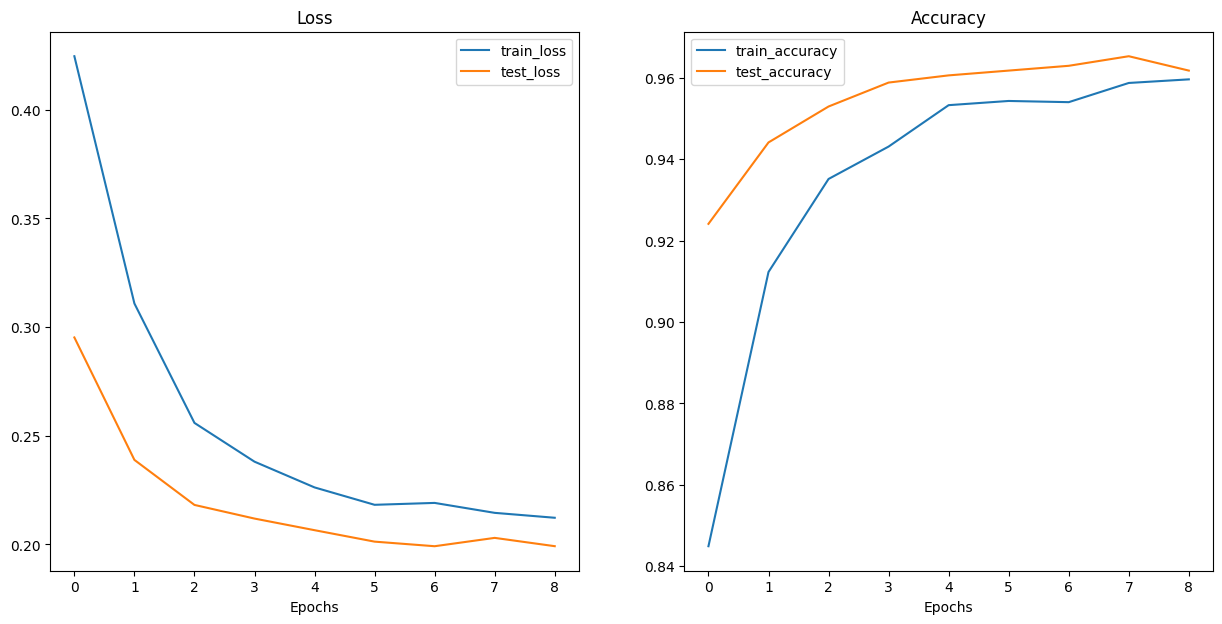

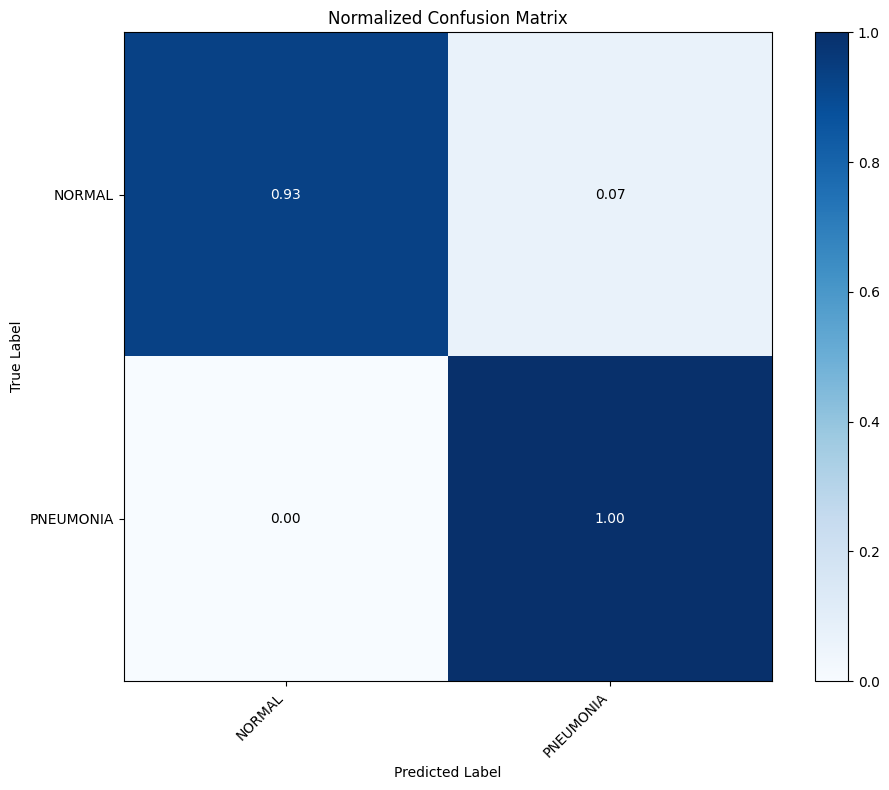

In [8]:
def _merge_phase_results(run_object):
    merged = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
    }
    for phase_results in (run_object.warmup_results, run_object.fine_tune_results):
        if phase_results is None:
            continue
        for key in merged:
            merged[key].extend(phase_results[key])
    return merged


merged_results = _merge_phase_results(run)
phase_summary = pd.DataFrame(
    [
        {
            "phase": "head_warmup",
            "epochs": len(run.warmup_results["train_loss"]) if run.warmup_results is not None else 0,
            "val_accuracy": None if run.warmup_val_metrics is None else run.warmup_val_metrics["accuracy"],
            "val_macro_f1": None if run.warmup_val_metrics is None else run.warmup_val_metrics["macro_f1"],
            "val_auroc": None if run.warmup_val_metrics is None else run.warmup_val_metrics["auroc"],
        },
        {
            "phase": "selected_final_model",
            "epochs": len(merged_results["train_loss"]),
            "val_accuracy": run.val_metrics["accuracy"],
            "val_macro_f1": run.val_metrics["macro_f1"],
            "val_auroc": run.val_metrics["auroc"],
        },
    ]
).set_index("phase")
display(phase_summary.round(4))

split_metrics = pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": run.val_metrics["accuracy"],
            "balanced_accuracy": run.val_metrics["balanced_accuracy"],
            "macro_f1": run.val_metrics["macro_f1"],
            "macro_precision": run.val_metrics["macro_precision"],
            "macro_recall": run.val_metrics["macro_recall"],
            "weighted_f1": run.val_metrics["weighted_f1"],
            "auroc": run.val_metrics["auroc"],
            "average_precision": run.val_metrics["average_precision"],
        },
        {
            "split": "test",
            "accuracy": run.test_metrics["accuracy"],
            "balanced_accuracy": run.test_metrics["balanced_accuracy"],
            "macro_f1": run.test_metrics["macro_f1"],
            "macro_precision": run.test_metrics["macro_precision"],
            "macro_recall": run.test_metrics["macro_recall"],
            "weighted_f1": run.test_metrics["weighted_f1"],
            "auroc": run.test_metrics["auroc"],
            "average_precision": run.test_metrics["average_precision"],
        },
    ]
).set_index("split")
display(split_metrics.round(4))

per_class_metrics = pd.DataFrame(
    {
        "precision": run.test_metrics["per_class_precision"],
        "recall": run.test_metrics["per_class_recall"],
        "f1": run.test_metrics["per_class_f1"],
        "support": run.test_metrics["per_class_support"],
    }
).loc[run.class_names]
display(per_class_metrics.round(4))

print(f"Selected phase: {run.selected_phase}")
print(f"Best checkpoint: {run.best_checkpoint_path}")
print(f"Last checkpoint: {run.last_checkpoint_path}")

if merged_results["train_loss"]:
    curves_figure = plot_loss_curves(merged_results)
    curves_figure.show()

confusion_figure = plot_confusion_matrix(
    confusion_matrix_values=run.test_metrics["normalized_confusion_matrix"],
    class_names=run.class_names,
    normalize=True,
)
confusion_figure.show()


In [9]:
summary(
    run.model,
    input_size=(1, 3, *config.image_size),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    row_settings=("var_names",),
    device=str(resolve_device(config.device)),
)


2026-04-18 09:34:58,431 | INFO | pytorch_engine.utils | Auto-detected device: cuda


Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]          [1, 2]                    --                        Partial
├─Sequential (features)                                      [1, 3, 224, 224]          [1, 1280, 7, 7]           --                        Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]          [1, 32, 112, 112]         --                        False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]          [1, 32, 112, 112]         (864)                     False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]         [1, 32, 112, 112]         (64)                      False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]         [1, 32, 112, 112]         --       